In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]


In [2]:
file_caII = '/Users/coletamburri/Desktop/11Aug2024_Cclass_calibrated_CaIIH.npz'
file_hbeta = '/Users/coletamburri/Desktop/11Aug2024_Cclass_calibrated_Hbeta.npz'
ViSPcoords = '/Users/coletamburri/Desktop/11_Aug_2024_Cclass_Flare/Processed_ViSP_VBI_11Aug2024/ViSPcoords.npz'

hbeta_low =443
hbeta_high = 680

caII_low = 570
caII_high = 700

hepsilon_low = 775
hepsilon_high = 900

nsteps = 91
start = 57 #143 for saved Hbeta spectra
nframes = 10

In [3]:
# load caII
res_caII = np.load(file_caII)
res_hbeta = np.load(file_hbeta)
dkist_coords = np.load(ViSPcoords)

In [4]:
xarr_caII = dkist_coords['xarr_caII']
yarr_caII = dkist_coords['yarr_caII']

xarr_hbeta = dkist_coords['xarr_hbeta']
yarr_hbeta = dkist_coords['yarr_hbeta']

In [5]:
flare_arr_caII = res_caII['flare']
wave_caII = res_caII['wl']

flare_arr_hbeta = res_hbeta['flare']
wave_hbeta = res_hbeta['wl']

times=res_caII['times'];

In [6]:
bestseeingcaII_red = flare_arr_caII[148:237,caII_high,:]
bestseeingcaII_blue = flare_arr_caII[148:237,caII_low,:]

(1500.0, 500.0)

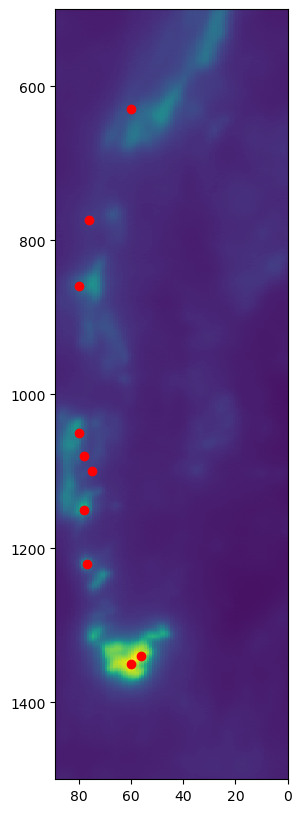

In [7]:
#region A, region B, region C, Region D1, region D2, region Asymm, region Asymm with red,  region Bkern, region Bblue, region Binit
xsel = [80,78,77,60,56,75,78,80,76,60]
ysel = [1050,1150,1220,1350,1340,1100,1080,860,774,630]

fig,ax=plt.subplots(figsize=(3,10))
ax.pcolormesh(np.transpose(bestseeingcaII_red))
ax.invert_xaxis()
ax.invert_yaxis()
ax.scatter(xsel,ysel,color='red')
ax.set_ylim([1500,500])

In [428]:
n_points = 10
colors = plt.cm.jet(np.linspace(0,1,n_points))


In [ ]:
i = 8

xch = xsel[i]
ych = ysel[i]
#plot with ViSP time series

# ID VISP coord

caII_xc = xarr_caII[xch]
caII_yc = yarr_caII[ych]

#get vbi blue coordinates
xchhbeta, hb_xc = find_nearest(xarr_hbeta,caII_xc)
ychhbeta, hb_yc = find_nearest(yarr_hbeta,caII_yc)

fig,ax=plt.subplots(1,2,figsize=(10,5),dpi=200)

for j in range(-1,9,1):
    ax.flatten()[0].plot(wave_caII,flare_arr_caII[148+xch+91*j,:,ych],color=colors[j+1])
    ax.flatten()[1].plot(wave_hbeta,flare_arr_hbeta[148+xchhbeta+91*j,:,ychhbeta],color=colors[j+1])

ax.flatten()[0].set_xlim([396.7,397.08])
ax.flatten()[1].set_xlim([486.0,486.35])
ax.flatten()[0].set_ylim([-1e6,6.5e6])
ax.flatten()[1].set_ylim([-1e6,6.5e6])

ax.flatten()[0].set_xlabel('Wavelength [nm]',fontsize=12)
ax.flatten()[0].set_ylabel(r'Intensity [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$ sr$^{-1}$]',fontsize=12)

ax.flatten()[1].set_xlabel('Wavelength [nm]',fontsize=12)
ax.flatten()[1].set_ylabel(r'Intensity [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$ sr$^{-1}$]',fontsize=12)

ax.flatten()[0].grid('on')
ax.flatten()[1].grid('off')

ax.flatten()[0].set_xticks([396.7,396.8,396.9,397,397.1])
ax.flatten()[1].set_xticks([486,486.1,486.2,486.3])





Error in callback <function _draw_all_if_interactive at 0x116862f20> (for post_execute), with arguments args (),kwargs {}:


In [ ]:
fig,ax=plt.subplots(2,5,figsize=(8,5),dpi=150)

if i == 3 or i == 4:
    ylo=-250
    yhi=-240
    xlo=759
    xhi=766

if i==0 or i ==1 or i==2 or i==5 or i ==6:
    ylo=-245
    yhi=-235
    xlo=759
    xhi=766

if i>6:
    ylo=-235
    yhi=-220
    xlo=759
    xhi=766

for j in range(10):
    if i<8:
        ax.flatten()[j].pcolormesh(xarr_caII[:-1],yarr_caII,np.transpose(flare_arr_caII[57+(91*j):56+(91*(j+1)),caII_high,:]),cmap='grey',alpha=1)
    else:
        ax.flatten()[j].pcolormesh(xarr_caII[:-1],yarr_caII,np.transpose(flare_arr_caII[57+(91*j):56+(91*(j+1)),caII_low,:]),cmap='grey',alpha=1)
   
    #xsel=xsel-lower_threshold+xlo

    ax.flatten()[j].scatter(caII_xc,caII_yc,40,color=colors[j],alpha=1,marker='o')

    #ax.flatten()[i].set_ylim([yhi,ylo])
    ax.flatten()[j].set_ylim([ylo,yhi])
    ax.flatten()[j].set_xlim([xlo,xhi])
    ax.flatten()[j].tick_params(axis='x', labelrotation=45)
    ax.flatten()[j].tick_params(axis='y', labelrotation=45)
    
    ax.flatten()[j].tick_params(axis='x',labelsize=6)
    ax.flatten()[j].set_xticks([760,762,764])
    ax.flatten()[j].tick_params(axis='y',labelsize=6)
    ax.flatten()[j].set_title(times[57+91*j][11:19],fontsize=8)
    #ax.flatten()[i].set_xticks([760,763,766])
ax.flatten()[0].set_ylabel('DKIST HPC-y [arcsec]',fontsize=6)
ax.flatten()[5].set_ylabel('DKIST HPC-y [arcsec]',fontsize=6)

ax.flatten()[7].set_xlabel('DKIST HPC-x [arcsec]',fontsize=6)
fig.tight_layout(pad=2.0) 
fig.subplots_adjust(hspace=0.5,wspace=0.3)

ERROR! Session/line number was not unique in database. History logging moved to new session 1742
